In [1]:
#básicas, importar siempre
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
#df -> data frameworj¿k
df = pd.read_csv("antenas.csv")
#df.head()  #primeros 5
df

,antena,descarga
0,1,70
1,2,120
2,3,140
3,4,190
4,5,70
5,1,70
6,2,170
7,3,180
8,4,250
9,5,100


Text(5.069444444444445, 0.5, 'Descarga(Mbps)')

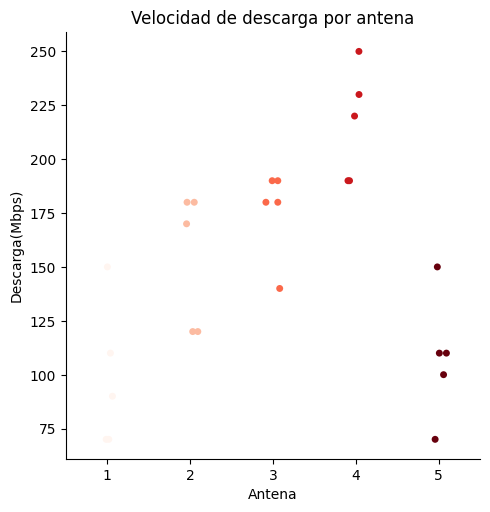

In [3]:
#gráfica
sns.catplot(x='antena', y='descarga', hue='antena', data=df, palette='Reds', legend=False)
plt.title("Velocidad de descarga por antena")
plt.xlabel("Antena")
plt.ylabel("Descarga(Mbps)")

Text(0, 0.5, 'Descarga(Mbps)')

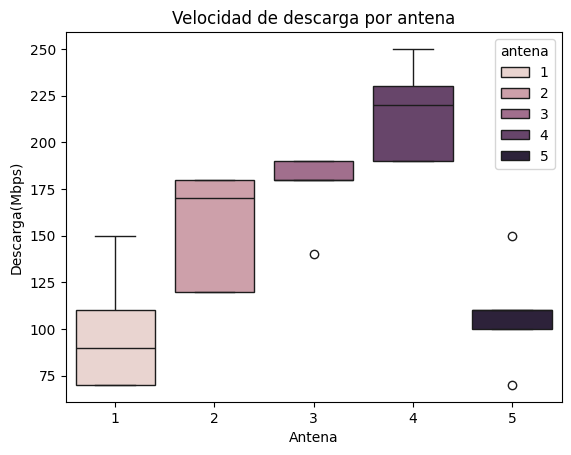

In [4]:
sns.boxplot(x='antena', y='descarga', hue='antena', data=df, orient="v")
plt.title("Velocidad de descarga por antena")
plt.xlabel("Antena")
plt.ylabel("Descarga(Mbps)")


In [5]:
import scipy.stats as stats
f_statistic, p_value = stats.f_oneway(df.descarga[df.antena==1], df.descarga[df.antena==2], df.descarga[df.antena==3], df.descarga[df.antena==4], df.descarga[df.antena==5])
print("F Statistic:", f_statistic)
print("p_value:", p_value)
alpha=0.05
if p_value > alpha:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente para concluir que existe una diferencia significativa entre las velocidades")
else:
    print("Se rechaza la hipótesis nula: existe al menos una diferencia significativa entre las velocidades")

F Statistic: 14.756823821339944
p_value: 9.127937124058487e-06
Se rechaza la hipótesis nula: existe al menos una diferencia significativa entre las velocidades


#SST (Suma de cuadrados totales) = SSTratamentos + SSError

##F (fisher) = (SSTrat. /grados de libertad) / (SSE / grados de libertad)

F = (SSTrar / 5-1) / (SSE/20)  

  SST -> CADA DATO - EL PROMEDIO DE TODO -> VARIANZA
      -> 24 GRADOS DE LIBERTAD EN TOTAL

EN TEORIA PUEDE TOMAR VALORES DE 0 A INF. PERO EL 95% DE LAS VECES, ¿CUAL ES EL VALOR?

SI LO HACEMOS 100 VECES, EL 95% DE LAS VECES DEBE DAR 2.86

NUESTRA F DIO 14.7 -> F Statistic: 14.756823821339944

CONCLUSIÓN:
-> SSTrat es mucho más grande que SSE
-> Las antenas sí presentan diferencia en sus velocidades


HIPOTESIS NULA (H0) = No existe diferencia significativa en la velocidad de descar promedio entre las  antenas.

HIPÓTESIS ALTERNATIVA (H1) = Existe al menos una antena que tiene una velocidad de descargar promedio,¿ diferente a las demás.

#P VALOR
 Si p < 0.05 rechazamos H0

 ALFHA = NIVEL DE SIGNIFICANCIA

 ##ERROR TIPO 1 -> RECHAZADO ALGO VERDADERO
 ##ERROR TIPO 2 -> ACEPTADO ALGO FALSO

 p_value: 9.127937124058487e-06   <<< O.OO5 -> RECHAZAMOS LA HIPOTESIS NULA

In [7]:
#ANOVA

#H1 -> AL MENOS UNA ANTENA ES DIF.
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('descarga ~ C(antena)', data=df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table)

# Explicame la descarga en términos de la antena

            sum_sq    df          F    PR(>F)
C(antena)  47576.0   4.0  14.756824  0.000009
Residual   16120.0  20.0        NaN       NaN


            sum_sq    df          F    PR(>F)
C(antena)  47576.0   4.0  14.756824  0.000009
Residual   16120.0  20.0        NaN       NaN


df -> grados de libertad
p valor -> 0.000009
SSTratamientos ->  47576.0
SSO -> 16120.0
f de fisher ->  14.756824

Si se rechaza la hipotesis nula, es el siguiente paso saber cual es la más rápida o lenta

## COMPARACIONES EN PAREJAS
## PRUEBA DE TUKEY
 -HACE TODAS LAS COMPARACIONES Y AL AGRUPAR SOLO SE COMETE UN ERROR TIPO I
 -FACILIDAD DE INTERPRETACIÓN

#HIPOTESIS ESTADÍSTICA
  -H0 (NULA) -> NO EXISTE DIF. SIG. EN VEL. DE DESCATGA PROM. ENTRE LAS DOS ANTENAS.
  H1 (ALT) -> PROMEDIO DE DESCARGA CON DIFERENCIA SIGN.




In [8]:
import statsmodels.stats.multicomp as mc

tukey = mc.pairwise_tukeyhsd(df['descarga'], df['antena'], alpha=0.05)
print(tukey)
# DESCAR EXPLICADO POR ANTENA

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2     56.0 0.0385    2.2704 109.7296   True
     1      3     78.0 0.0026   24.2704 131.7296   True
     1      4    118.0    0.0   64.2704 171.7296   True
     1      5     10.0 0.9798  -43.7296  63.7296  False
     2      3     22.0 0.7372  -31.7296  75.7296  False
     2      4     62.0 0.0189    8.2704 115.7296   True
     2      5    -46.0 0.1163  -99.7296   7.7296  False
     3      4     40.0 0.2101  -13.7296  93.7296  False
     3      5    -68.0 0.0091 -121.7296 -14.2704   True
     4      5   -108.0 0.0001 -161.7296 -54.2704   True
-------------------------------------------------------


- PRIMERA FILA ->  COMPARANDO ANTENA 1 CON ANTENA 2
- SEGUNDA FILA -> COMPARANDO ANTENA 1 CON ANTENA 3    VELOCIDAD DISTINTA

- COMPARANDO ANTENA 1 CON ANTENA 5 -> NO SE RECHAZA LA HIPOTESIS NULA
IGUALES


-------------------------------------------------------
Multiple Comparison of Means - Tukey HSD, FWER=0.05  
-------------------------------------------------------
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2     56.0 0.0385    2.2704 109.7296   True
     1      3     78.0 0.0026   24.2704 131.7296   True
     1      4    118.0    0.0   64.2704 171.7296   True
     1      5     10.0 0.9798  -43.7296  63.7296  False
     2      3     22.0 0.7372  -31.7296  75.7296  False
     2      4     62.0 0.0189    8.2704 115.7296   True
     2      5    -46.0 0.1163  -99.7296   7.7296  False
     3      4     40.0 0.2101  -13.7296  93.7296  False
     3      5    -68.0 0.0091 -121.7296 -14.2704   True
     4      5   -108.0 0.0001 -161.7296 -54.2704   True
-------------------------------------------------------
*P < 0.05 SE RECHAZA*


#VALIDACION DEL MODELO

## Las suposiciones que fundamentan  el análisis de varianza son que los residuos y errores:

- están normalmente distribuido
- con media cero y varianza cons
- estos son independientes

GRÁFICA CUANTIL- CUANTIL
- LINEA ROJA, SON LOS CUANTILES DE UNA DISTRIBUCIÓN NORMAL PERFECTA
- PUNTOS AZULES, CUANTILES DE DISTRIBUCIÓN DE NUESTROS DATOS


GRÁFCIA PARA PROBAR QUE LA VARIANZA ES CONSTANTE
- Si la var. no fuera const. =

- NO SE DEBE VER -> Cono -> Ni que vaya subiendo
- SÍ SE DEBE VER ->